In [1]:
import os
import glob 
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 2
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

2026-04-18 10:36:57.373448: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776508617.560980      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776508617.612807      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776508618.023551      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776508618.023586      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776508618.023589      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
def find_first_existing_dir(patterns):
    for pattern in patterns:
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]
    return None

# Tìm Dataset2 và Dataset3 trong /kaggle/input
DATASET2_DIR = find_first_existing_dir([
    "/kaggle/input/**/9CTscans_tiff/Dataset2",
    "/kaggle/input/**/Dataset2",
])

DATASET3_DIR = find_first_existing_dir([
    "/kaggle/input/**/9CTscans_tiff/Dataset3",
    "/kaggle/input/**/Dataset3",
])

if DATASET2_DIR is None:
    raise FileNotFoundError("Không tìm thấy thư mục Dataset2 trong /kaggle/input")

if DATASET3_DIR is None:
    raise FileNotFoundError("Không tìm thấy thư mục Dataset3 trong /kaggle/input")

print("DATASET2_DIR =", DATASET2_DIR)
print("DATASET3_DIR =", DATASET3_DIR)

DATASET2_DIR = /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2
DATASET3_DIR = /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3


In [3]:
def get_tiff_dirs(root_dir):
    all_tifs = glob.glob(os.path.join(root_dir, "**", "*.tif"), recursive=True)

    if len(all_tifs) == 0:
        return []

    tif_dirs = sorted(list(set(os.path.dirname(p) for p in all_tifs)))
    return tif_dirs

dataset2_subdirs = get_tiff_dirs(DATASET2_DIR)
dataset3_subdirs = get_tiff_dirs(DATASET3_DIR)

print("Các thư mục con trong Dataset2 có chứa TIFF:")
for d in dataset2_subdirs:
    print("-", d)

print("\nCác thư mục con trong Dataset3 có chứa TIFF:")
for d in dataset3_subdirs:
    print("-", d)

Các thư mục con trong Dataset2 có chứa TIFF:
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/1
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/2
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/3
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/4
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/5
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/6
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/7
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/8
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset2/9

Các thư mục con trong Dataset3 có chứa TIFF:
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_001
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_002
- /kaggle/input/datasets/thanhbn/pneumonia-da

In [4]:
def collect_triplets_from_dir(data_dir):
    triplets = []
    all_tifs = sorted(glob.glob(os.path.join(data_dir, "*.tif")))

    for img_path in all_tifs:
        name = os.path.basename(img_path)

        if name.endswith("_lung_mask.tif") or name.endswith("_mask.tif"):
            continue

        base = name[:-4]
        lung_path = os.path.join(data_dir, base + "_lung_mask.tif")
        lesion_path = os.path.join(data_dir, base + "_mask.tif")

        if os.path.exists(lung_path) and os.path.exists(lesion_path):
            triplets.append((img_path, lung_path, lesion_path, base))

    return triplets


def collect_triplets_from_many_dirs(dir_list):
    all_triplets = []
    for d in dir_list:
        all_triplets.extend(collect_triplets_from_dir(d))
    return all_triplets

In [5]:
def extract_patient_id(img_path, dataset_root=None):
    """
    Cố gắng suy ra patient_id từ đường dẫn ảnh.
    Ưu tiên dùng cấu trúc thư mục; nếu không đủ thông tin thì fallback sang tên file.
    """
    norm_path = os.path.normpath(img_path)

    if dataset_root is not None:
        try:
            rel_path = os.path.relpath(norm_path, dataset_root)
        except Exception:
            rel_path = norm_path
    else:
        rel_path = norm_path

    parts = rel_path.split(os.sep)
    filename = parts[-1]
    stem = os.path.splitext(filename)[0]

    # Nếu có thư mục cha bên trên file, dùng toàn bộ đường dẫn thư mục cha làm patient_id.
    # Cách này an toàn khi mỗi bệnh nhân nằm trong một thư mục riêng.
    if len(parts) > 1:
        parent_parts = parts[:-1]

        # bỏ các thư mục quá chung chung ở cuối nếu có
        generic_dirs = {"images", "image", "img", "imgs", "mask", "masks", "lung", "lesion", "tr_im", "val_im", "test_im"}
        while parent_parts and parent_parts[-1].lower() in generic_dirs:
            parent_parts = parent_parts[:-1]

        if parent_parts:
            return "/".join(parent_parts)

    # Fallback: suy ra từ tên file
    patient_stem = stem
    patient_stem = re.sub(r'(_lung_mask|_mask)$', '', patient_stem, flags=re.IGNORECASE)
    patient_stem = re.sub(r'([_-](slice|img|image|im|scan))?[_-]?\d+$', '', patient_stem, flags=re.IGNORECASE)

    if patient_stem.strip() == "":
        patient_stem = stem

    return patient_stem


def split_triplets_by_patient(triplets, dataset_root=None, train_ratio=0.9, seed=42):
    patient_to_triplets = {}

    for item in triplets:
        img_path, lung_path, lesion_path, sid = item
        patient_id = extract_patient_id(img_path, dataset_root=dataset_root)
        patient_to_triplets.setdefault(patient_id, []).append(item)

    patient_ids = sorted(patient_to_triplets.keys())
    rng = random.Random(seed)
    rng.shuffle(patient_ids)

    n_patients = len(patient_ids)
    n_train_patients = max(1, int(train_ratio * n_patients)) if n_patients > 1 else n_patients

    # đảm bảo vẫn còn patient cho val nếu có từ 2 patient trở lên
    if n_patients >= 2 and n_train_patients == n_patients:
        n_train_patients = n_patients - 1

    train_patient_ids = set(patient_ids[:n_train_patients])
    val_patient_ids = set(patient_ids[n_train_patients:])

    train_triplets = []
    val_triplets = []

    for pid, items in patient_to_triplets.items():
        if pid in train_patient_ids:
            train_triplets.extend(items)
        else:
            val_triplets.extend(items)

    return train_triplets, val_triplets, patient_to_triplets, train_patient_ids, val_patient_ids


# Dataset2 chỉ dùng để test
test_triplets = collect_triplets_from_many_dirs(dataset2_subdirs)

# Dataset3 dùng để train/val
dataset3_triplets = collect_triplets_from_many_dirs(dataset3_subdirs)

print("Số mẫu Dataset3:", len(dataset3_triplets))
print("Số mẫu Dataset2:", len(test_triplets))

if len(dataset3_triplets) == 0:
    raise ValueError("Dataset3 không có mẫu hợp lệ để train.")

if len(test_triplets) == 0:
    raise ValueError("Dataset2 không có mẫu hợp lệ để test.")

train_triplets, val_triplets, patient_to_triplets, train_patient_ids, val_patient_ids = split_triplets_by_patient(
    dataset3_triplets,
    dataset_root=DATASET3_DIR,
    train_ratio=0.9,
    seed=42,
)

train_overlap = train_patient_ids.intersection(val_patient_ids)

print("Số bệnh nhân Dataset3:", len(patient_to_triplets))
print("Số bệnh nhân train:", len(train_patient_ids))
print("Số bệnh nhân val  :", len(val_patient_ids))
print("Số mẫu train      :", len(train_triplets))
print("Số mẫu val        :", len(val_triplets))
print("Số mẫu test       :", len(test_triplets))
print("Bệnh nhân trùng giữa train và val:", len(train_overlap))

if len(train_overlap) > 0:
    print("Các patient_id bị trùng:", sorted(list(train_overlap))[:10])
    raise ValueError("Phát hiện rò rỉ bệnh nhân giữa train và val.")
else:
    print("OK: mỗi bệnh nhân chỉ nằm trong đúng một tập train hoặc val.")

print("\nVí dụ 10 patient_id train đầu tiên:")
for pid in sorted(list(train_patient_ids))[:10]:
    print("-", pid)

print("\nVí dụ 10 patient_id val đầu tiên:")
for pid in sorted(list(val_patient_ids))[:10]:
    print("-", pid)


Số mẫu Dataset3: 3520
Số mẫu Dataset2: 829
Số bệnh nhân Dataset3: 20
Số bệnh nhân train: 18
Số bệnh nhân val  : 2
Số mẫu train      : 2949
Số mẫu val        : 571
Số mẫu test       : 829
Bệnh nhân trùng giữa train và val: 0
OK: mỗi bệnh nhân chỉ nằm trong đúng một tập train hoặc val.

Ví dụ 10 patient_id train đầu tiên:
- coronacases_002
- coronacases_003
- coronacases_005
- coronacases_006
- coronacases_007
- coronacases_008
- coronacases_009
- coronacases_010
- radiopaedia_10_85902_1
- radiopaedia_10_85902_3

Ví dụ 10 patient_id val đầu tiên:
- coronacases_001
- coronacases_004


In [6]:
def _read_tif_cv2(path):
    # chuyển mọi kiểu input về str Python
    if isinstance(path, tf.Tensor):
        path = path.numpy()

    if isinstance(path, np.ndarray):
        path = path.item()

    if isinstance(path, bytes):
        path = path.decode("utf-8")

    path = str(path)

    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Không đọc được ảnh: {path}")

    img = img.astype(np.float32)

    if img.ndim == 3:
        if img.shape[-1] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            img = img[..., 0]

    return img[..., np.newaxis]   # (H, W, 1)


def read_tif_tf(path):
    img = tf.numpy_function(_read_tif_cv2, [path], tf.float32)
    img.set_shape([None, None, 1])
    return img

In [7]:
USE_LUNG_CROP = True
USE_LUNG_MASKING = True

def crop_to_lung_region(img, lung, lesion, margin=10):
    lung_bin = tf.cast(lung > 127.0, tf.float32)
    coords = tf.cast(tf.where(lung_bin[..., 0] > 0), tf.int32)

    def do_crop():
        y_min = tf.maximum(tf.reduce_min(coords[:, 0]) - margin, 0)
        y_max = tf.minimum(tf.reduce_max(coords[:, 0]) + margin + 1, tf.shape(img)[0])
        x_min = tf.maximum(tf.reduce_min(coords[:, 1]) - margin, 0)
        x_max = tf.minimum(tf.reduce_max(coords[:, 1]) + margin + 1, tf.shape(img)[1])

        return (
            img[y_min:y_max, x_min:x_max, :],
            lung[y_min:y_max, x_min:x_max, :],
            lesion[y_min:y_max, x_min:x_max, :]
        )

    return tf.cond(tf.shape(coords)[0] > 0, do_crop, lambda: (img, lung, lesion))


def normalize_image(img):
    return (img - tf.reduce_min(img)) / (tf.reduce_max(img) - tf.reduce_min(img) + 1e-7)


def preprocess_pneumonia(img_path, lung_path, lesion_path):
    img = read_tif_tf(img_path)
    lung = read_tif_tf(lung_path)
    lesion = read_tif_tf(lesion_path)

    if USE_LUNG_CROP:
        img, lung, lesion = crop_to_lung_region(img, lung, lesion)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    lung = tf.image.resize(lung, (IMG_SIZE, IMG_SIZE), method="nearest")
    lesion = tf.image.resize(lesion, (IMG_SIZE, IMG_SIZE), method="nearest")

    lung = tf.cast(lung > 127.0, tf.float32)
    lesion = tf.cast(lesion > 127.0, tf.float32)

    img = normalize_image(img)

    if USE_LUNG_MASKING:
        img = img * lung

    img = tf.repeat(img, repeats=3, axis=-1)

    return img, lesion

In [8]:
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_brightness(img, max_delta=0.05)
        img = tf.clip_by_value(img, 0.0, 1.0)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_contrast(img, 0.95, 1.05)
        img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

In [9]:
def make_dataset(triplets_list, training=False):
    img_paths = [x[0] for x in triplets_list]
    lung_paths = [x[1] for x in triplets_list]
    lesion_paths = [x[2] for x in triplets_list]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, lung_paths, lesion_paths))

    ds = ds.map(
        lambda a, b, c: preprocess_pneumonia(a, b, c),
        num_parallel_calls=AUTOTUNE
    )

    if training:
        ds = ds.shuffle(512, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_triplets, training=True)
val_ds   = make_dataset(val_triplets, training=False)
test_ds  = make_dataset(test_triplets, training=False)

xb, yb = next(iter(train_ds))
print("Train batch input shape:", xb.shape)
print("Train batch mask shape :", yb.shape)

I0000 00:00:1776508682.055110      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776508682.060791      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train batch input shape: (2, 224, 224, 3)
Train batch mask shape : (2, 224, 224, 1)


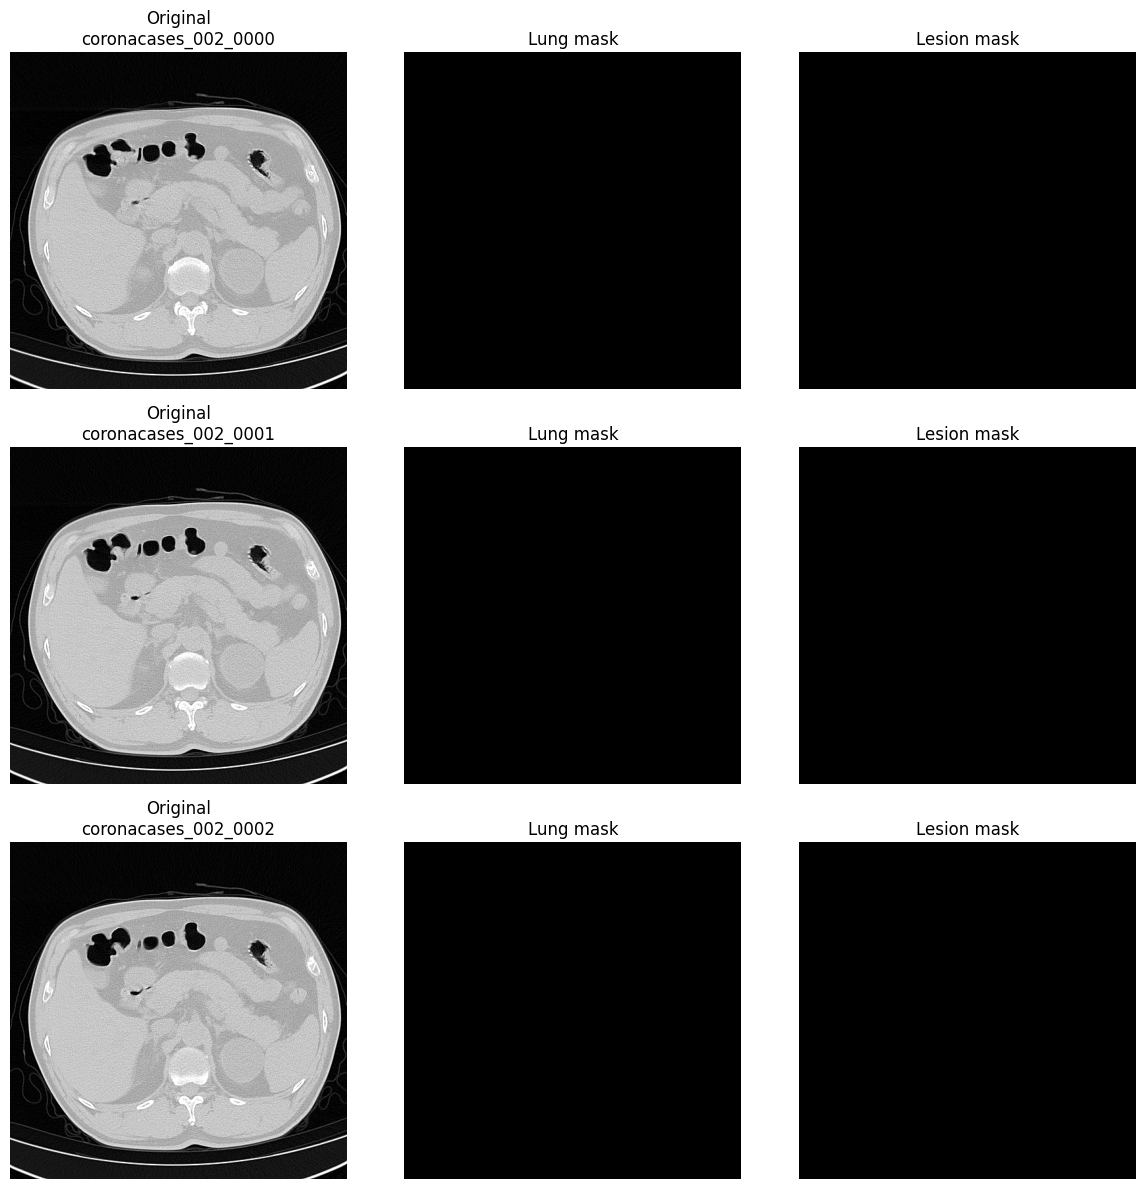

In [10]:
def show_three_raw_samples(triplets_list, start_idx=0):
    selected = triplets_list[start_idx:start_idx + 3]
    n = len(selected)

    if n == 0:
        print("Không có mẫu nào để hiển thị.")
        return

    plt.figure(figsize=(12, 4 * n))

    for i, (img_p, lung_p, lesion_p, sid) in enumerate(selected):
        img = _read_tif_cv2(img_p)
        lung = _read_tif_cv2(lung_p) if lung_p is not None and os.path.exists(lung_p) else None
        lesion = _read_tif_cv2(lesion_p) if lesion_p is not None and os.path.exists(lesion_p) else None

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(img[..., 0], cmap="gray")
        plt.title(f"Original\n{sid}")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        if lung is not None:
            plt.imshow(lung[..., 0], cmap="gray")
        else:
            plt.text(0.5, 0.5, "None", ha="center", va="center")
        plt.title("Lung mask")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        if lesion is not None:
            plt.imshow(lesion[..., 0], cmap="gray")
        else:
            plt.text(0.5, 0.5, "None", ha="center", va="center")
        plt.title("Lesion mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_three_raw_samples(train_triplets, start_idx=0)

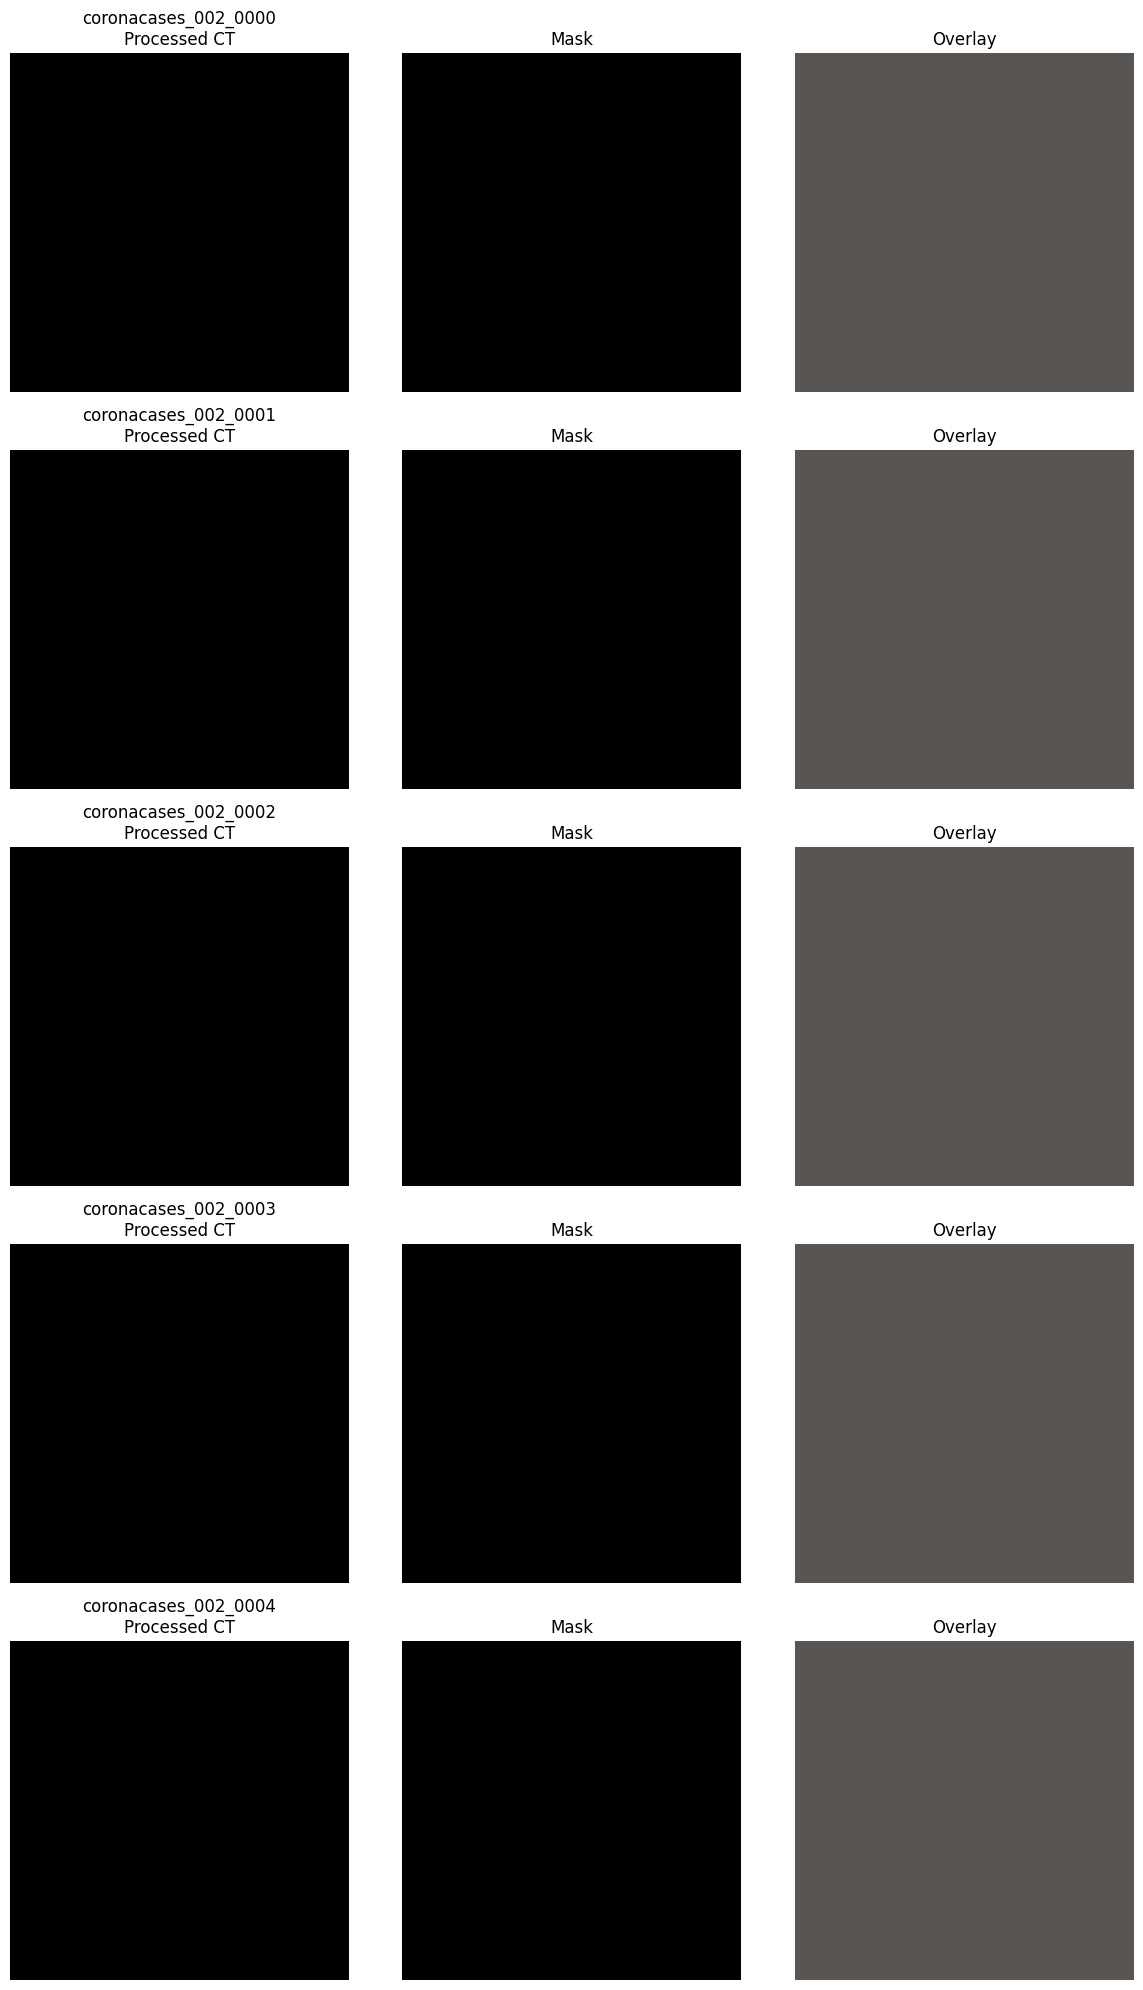

In [11]:
def show_5_processed_rows(triplets_list, start_idx=0):
    n = min(5, len(triplets_list) - start_idx)
    if n <= 0:
        print("Không có dữ liệu để hiển thị.")
        return

    plt.figure(figsize=(12, 4 * n))

    for i in range(n):
        img_p, lung_p, lesion_p, sid = triplets_list[start_idx + i]

        x, y = preprocess_pneumonia(img_p, lung_p, lesion_p)

        img_show = x.numpy()[..., 0]
        mask_show = y.numpy()[..., 0]

        plt.subplot(n, 3, i * 3 + 1)
        plt.title(f"{sid}\nProcessed CT")
        plt.imshow(img_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.title("Mask")
        plt.imshow(mask_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.title("Overlay")
        plt.imshow(img_show, cmap="gray")
        plt.imshow(mask_show, cmap="Reds", alpha=0.35)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_5_processed_rows(train_triplets, start_idx=0)

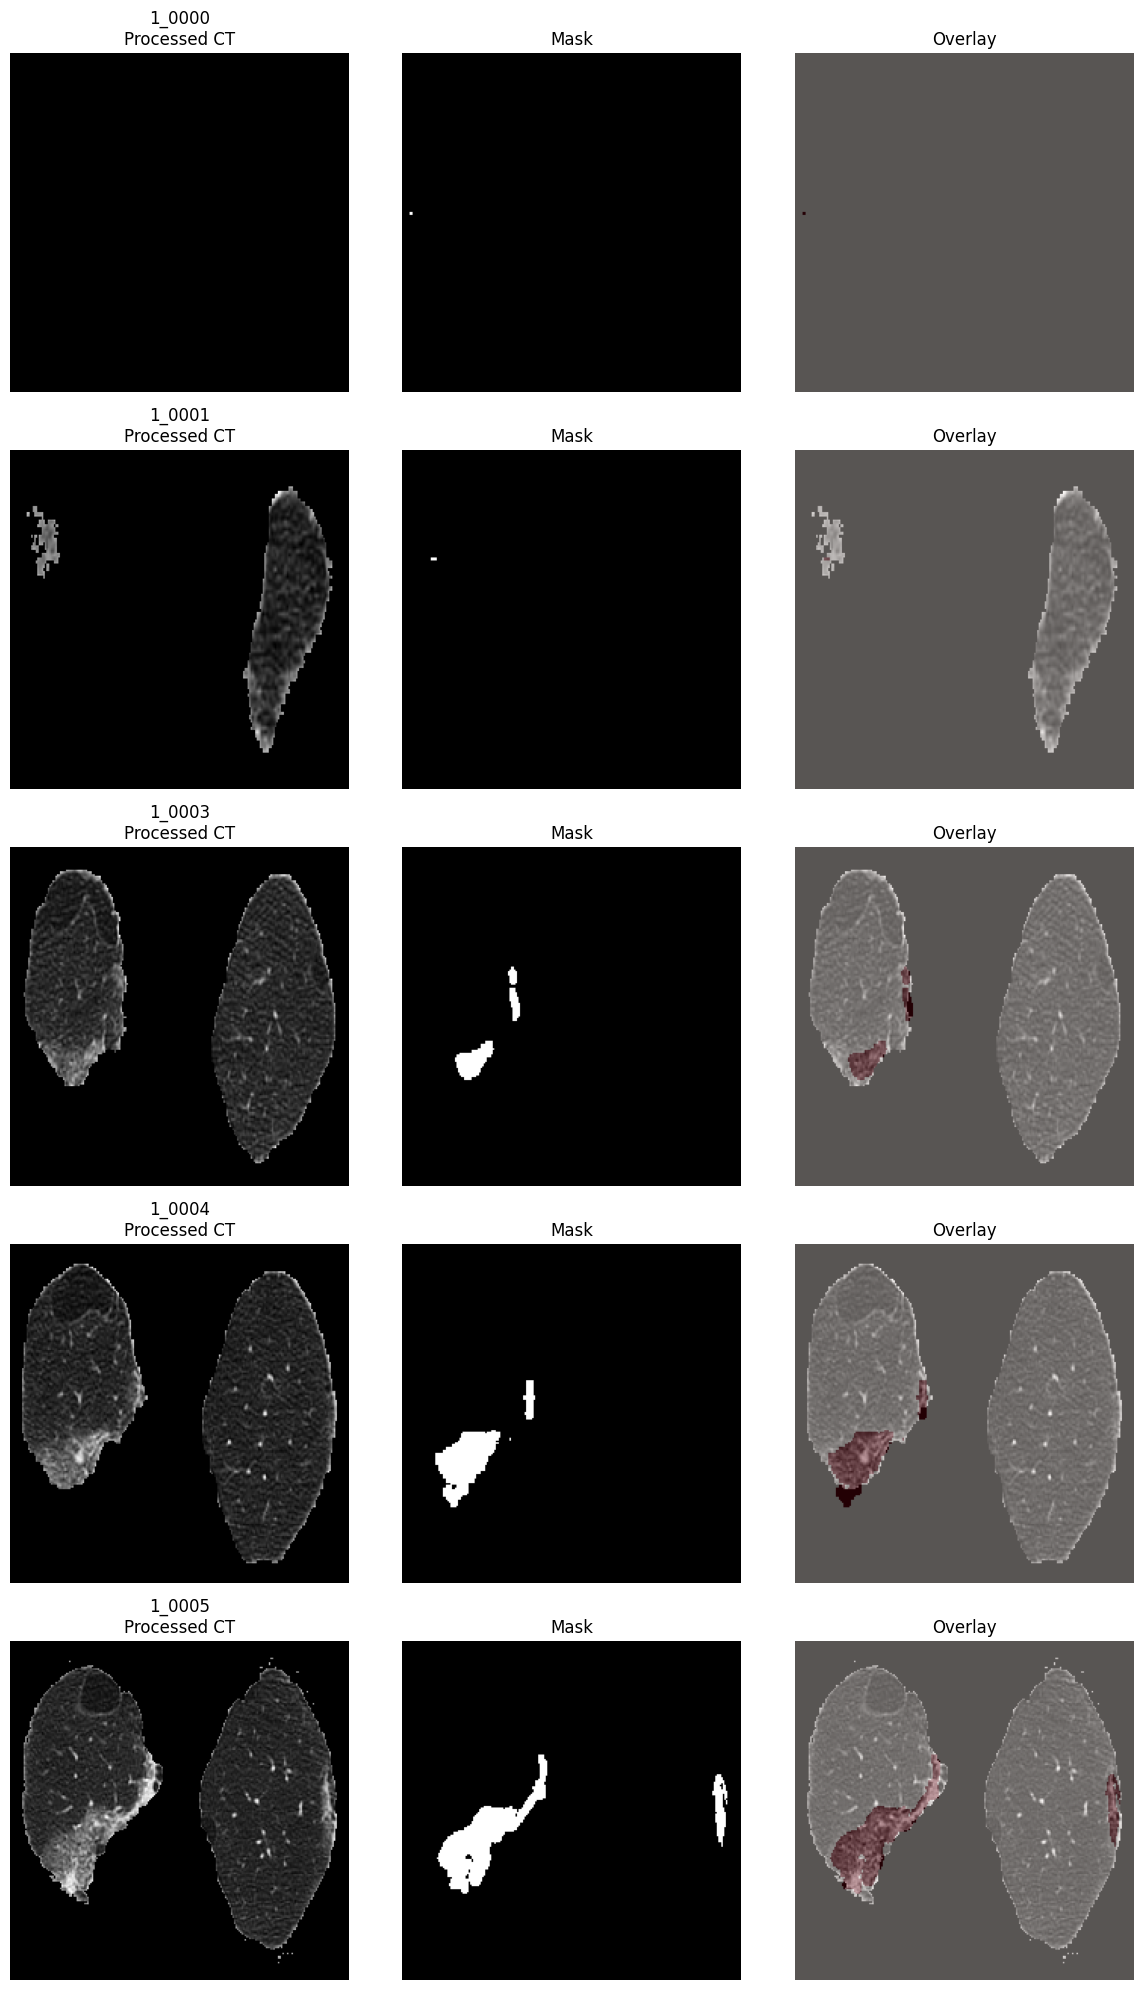

In [12]:
def show_5_positive_processed_rows(triplets_list, start_idx=0):
    positive_samples = []

    for img_p, lung_p, lesion_p, sid in triplets_list:
        lesion_raw = _read_tif_cv2(lesion_p)[..., 0]
        if np.any(lesion_raw > 0):
            positive_samples.append((img_p, lung_p, lesion_p, sid))

    if len(positive_samples) == 0:
        print("Không tìm thấy mẫu nào có tổn thương.")
        return

    selected = positive_samples[start_idx:start_idx + 5]
    n = len(selected)

    if n == 0:
        print("start_idx vượt quá số mẫu có tổn thương.")
        return

    plt.figure(figsize=(12, 4 * n))

    for i, (img_p, lung_p, lesion_p, sid) in enumerate(selected):
        x, y = preprocess_pneumonia(img_p, lung_p, lesion_p)

        img_show = x.numpy()[..., 0]
        mask_show = y.numpy()[..., 0]

        plt.subplot(n, 3, i * 3 + 1)
        plt.title(f"{sid}\nProcessed CT")
        plt.imshow(img_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.title("Mask")
        plt.imshow(mask_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.title("Overlay")
        plt.imshow(img_show, cmap="gray")
        plt.imshow(mask_show, cmap="Reds", alpha=0.35)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_5_positive_processed_rows(test_triplets, start_idx=0)

## Xây dựng mô hình theo hướng tương đồng với file paper-style

- Giữ nguyên phần tiền xử lý dữ liệu và chia train/val/test phía trên.
- Chuyển phần mô hình sang kiến trúc encoder-decoder với nested skip pathways.
- Dùng tổ hợp loss `0.4 Dice + 0.4 IoU + 0.2 BCE`.
- Dùng Adam với learning rate `1e-3`.

In [13]:
from tensorflow.keras import layers, Model

BACKBONE = "B0"          # có thể đổi sang B3 hoặc B7 nếu đủ VRAM
ACTIVATION = "relu"      # relu | leaky_relu | elu | prelu | tanh
FREEZE_ENCODER = False
USE_IMAGENET = True


def get_backbone(name="B0", input_shape=(IMG_SIZE, IMG_SIZE, 3), weights="imagenet"):
    name = name.upper()

    if name == "B0":
        base = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights=weights,
            input_shape=input_shape,
        )
    elif name == "B3":
        base = tf.keras.applications.EfficientNetB3(
            include_top=False,
            weights=weights,
            input_shape=input_shape,
        )
    elif name == "B7":
        base = tf.keras.applications.EfficientNetB7(
            include_top=False,
            weights=weights,
            input_shape=input_shape,
        )
    else:
        raise ValueError("BACKBONE phải là B0, B3 hoặc B7")

    skips = [
        base.get_layer("block2a_expand_activation").output,  # 1/2
        base.get_layer("block3a_expand_activation").output,  # 1/4
        base.get_layer("block4a_expand_activation").output,  # 1/8
        base.get_layer("block6a_expand_activation").output,  # 1/16
    ]
    bottleneck = base.output                                  # 1/32
    return base, base.input, skips, bottleneck


def apply_activation(x, activation="relu", name=None):
    activation = activation.lower()

    if activation == "relu":
        return layers.Activation("relu", name=name)(x)
    if activation == "leaky_relu":
        return layers.LeakyReLU(negative_slope=0.1, name=name)(x)
    if activation == "elu":
        return layers.ELU(alpha=1.0, name=name)(x)
    if activation == "prelu":
        return layers.PReLU(shared_axes=[1, 2], name=name)(x)
    if activation == "tanh":
        return layers.Activation("tanh", name=name)(x)

    raise ValueError("ACTIVATION không hợp lệ")


def conv_block(x, filters, activation="relu", name_prefix="block"):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name_prefix}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn1")(x)
    x = apply_activation(x, activation=activation, name=f"{name_prefix}_act1")

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name_prefix}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn2")(x)
    x = apply_activation(x, activation=activation, name=f"{name_prefix}_act2")
    return x


def nested_skip_block(skip_tensors, up_tensor, filters, activation="relu", name_prefix="node"):
    x = layers.UpSampling2D((2, 2), interpolation="bilinear", name=f"{name_prefix}_up")(up_tensor)
    x = layers.Concatenate(name=f"{name_prefix}_concat")([*skip_tensors, x])
    x = conv_block(x, filters, activation=activation, name_prefix=name_prefix)
    return x


def build_novel_unet(backbone_name="B0", input_shape=(IMG_SIZE, IMG_SIZE, 3), activation="relu"):
    weights = "imagenet" if USE_IMAGENET else None
    base, inputs, skips, bottleneck = get_backbone(backbone_name, input_shape, weights=weights)
    base.trainable = not FREEZE_ENCODER

    x0_0, x1_0, x2_0, x3_0 = skips
    x4_0 = conv_block(bottleneck, 512, activation=activation, name_prefix="x4_0")

    x3_1 = nested_skip_block([x3_0], x4_0, 256, activation=activation, name_prefix="x3_1")
    x2_1 = nested_skip_block([x2_0], x3_0, 128, activation=activation, name_prefix="x2_1")
    x1_1 = nested_skip_block([x1_0], x2_0, 64, activation=activation, name_prefix="x1_1")
    x0_1 = nested_skip_block([x0_0], x1_0, 32, activation=activation, name_prefix="x0_1")

    x2_2 = nested_skip_block([x2_0, x2_1], x3_1, 128, activation=activation, name_prefix="x2_2")
    x1_2 = nested_skip_block([x1_0, x1_1], x2_1, 64, activation=activation, name_prefix="x1_2")
    x0_2 = nested_skip_block([x0_0, x0_1], x1_1, 32, activation=activation, name_prefix="x0_2")

    x1_3 = nested_skip_block([x1_0, x1_1, x1_2], x2_2, 64, activation=activation, name_prefix="x1_3")
    x0_3 = nested_skip_block([x0_0, x0_1, x0_2], x1_2, 32, activation=activation, name_prefix="x0_3")

    x0_4 = nested_skip_block([x0_0, x0_1, x0_2, x0_3], x1_3, 32, activation=activation, name_prefix="x0_4")

    out = layers.UpSampling2D((2, 2), interpolation="bilinear", name="final_up")(x0_4)
    out = conv_block(out, 32, activation=activation, name_prefix="final_refine")
    outputs = layers.Conv2D(1, 1, activation="sigmoid", name="mask")(out)

    return Model(inputs, outputs, name=f"NovelUNet_{backbone_name}_{activation}")


model = build_novel_unet(BACKBONE, activation=ACTIVATION)
model.summary()
print("Output shape:", model.output_shape)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "NovelUNet_B0_relu"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 18,773,956 (71.62 MB)

 Trainable params: 18,726,429 (71.44 MB)

 Non-trainable params: 47,527 (185.66 KB)

Output shape: (None, 224, 224, 1)


In [14]:
EPS = 1e-7

def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denominator = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
    return tf.reduce_mean((2.0 * intersection + EPS) / (denominator + EPS))

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3]) - intersection
    return tf.reduce_mean((intersection + EPS) / (union + EPS))

def iou_loss(y_true, y_pred):
    return 1.0 - iou_coef(y_true, y_pred)

def bce_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce)

def combo_loss(y_true, y_pred, alpha=0.4, beta=0.4, gamma=0.2):
    return (
        alpha * dice_loss(y_true, y_pred)
        + beta * iou_loss(y_true, y_pred)
        + gamma * bce_loss(y_true, y_pred)
    )

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=combo_loss,
    metrics=["accuracy", dice_coef, iou_coef]
)

In [15]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "novel_unet_best.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "novel_unet_latest.keras",
        save_best_only=False,
        verbose=0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

In [16]:
EPOCHS = 35

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/35


I0000 00:00:1776508748.812731      71 service.cc:152] XLA service 0x79f47c16d550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776508748.812779      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776508748.812783      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776508756.586401      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-18 10:39:26.519115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:39:26.652317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:39:27.381131: E external/local_xl

1474/1475 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9751 - dice_coef: 0.2849 - iou_coef: 0.2206 - loss: 0.6203

2026-04-18 10:42:29.723355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:42:29.858607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:42:30.643297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:42:30.778774: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 10:42:32.293324: E external/local_xla/xla/stream_

1475/1475 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9751 - dice_coef: 0.2849 - iou_coef: 0.2206 - loss: 0.6202
Epoch 1: val_dice_coef improved from -inf to 0.03548, saving model to novel_unet_best.keras
1475/1475 ━━━━━━━━━━━━━━━━━━━━ 316s 141ms/step - accuracy: 0.9751 - dice_coef: 0.2850 - iou_coef: 0.2207 - loss: 0.6202 - val_accuracy: 0.0612 - val_dice_coef: 0.0355 - val_iou_coef: 0.0191 - val_loss: 1.1779 - learning_rate: 0.0010
Epoch 2/35
1475/1475 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9895 - dice_coef: 0.4044 - iou_coef: 0.3351 - loss: 0.5145
Epoch 2: val_dice_coef did not improve from 0.03548
1475/1475 ━━━━━━━━━━━━━━━━━━━━ 143s 95ms/step - accuracy: 0.9895 - dice_coef: 0.4044 - iou_coef: 0.3351 - loss: 0.5145 - val_accuracy: 0.9823 - val_dice_coef: 1.2647e-04 - val_iou_coef: 1.2647e-04 - val_loss: 0.9987 - learning_rate: 0.0010
Epoch 3/35
1475/1475 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9908 - dice_coef: 0.4198 - iou_coef: 0.3537 - loss: 0.4995
Epoch 3: 

In [17]:
import json

with open("history.json", "w") as f:
    json.dump(history.history, f)

with open("last_epoch.txt", "w") as f:
    f.write(str(len(history.history["loss"])))

In [18]:
custom_objects = {
    "combo_loss": combo_loss,
    "dice_coef": dice_coef,
    "dice_loss": dice_loss,
    "iou_coef": iou_coef,
    "iou_loss": iou_loss,
    "bce_loss": bce_loss
}

best_model = tf.keras.models.load_model(
    "novel_unet_best.keras",
    custom_objects=custom_objects
)

print("Loaded best model.")

Loaded best model.


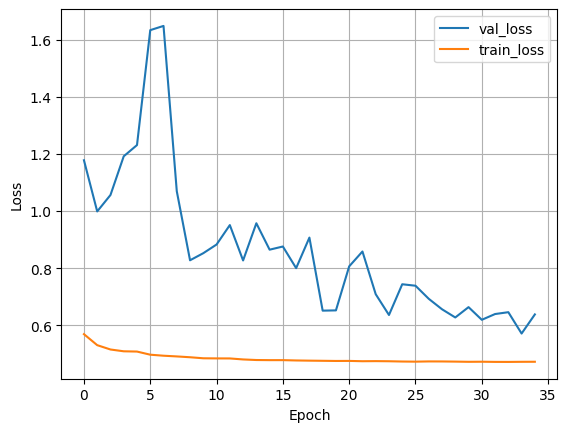

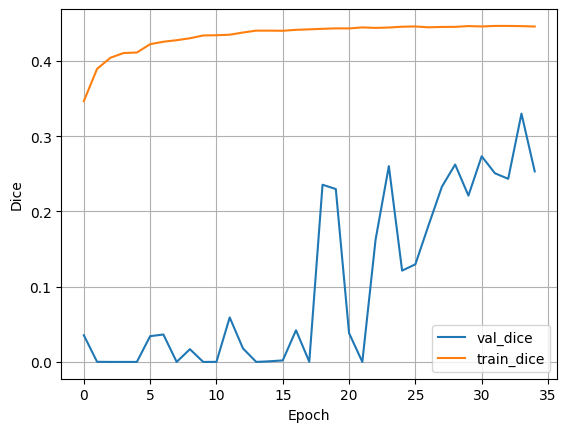

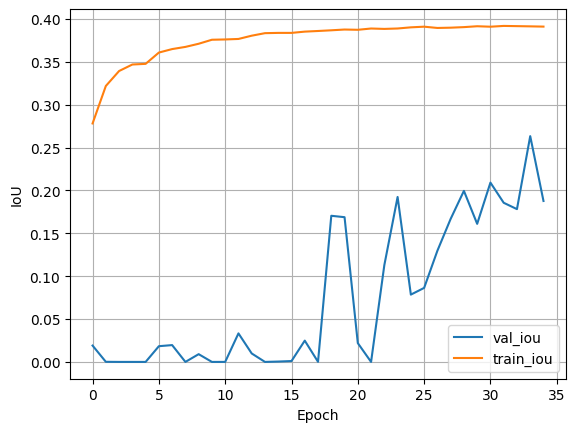

In [19]:
def plot_history_any(hist_or_dict):
    if hist_or_dict is None:
        print("Không có history để vẽ.")
        return

    if isinstance(hist_or_dict, dict):
        h = hist_or_dict
    else:
        h = hist_or_dict.history

    if "loss" in h:
        plt.figure()
        if "val_loss" in h:
            plt.plot(h["val_loss"], label="val_loss")
        plt.plot(h["loss"], label="train_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    if "dice_coef" in h:
        plt.figure()
        if "val_dice_coef" in h:
            plt.plot(h["val_dice_coef"], label="val_dice")
        plt.plot(h["dice_coef"], label="train_dice")
        plt.xlabel("Epoch")
        plt.ylabel("Dice")
        plt.legend()
        plt.grid(True)
        plt.show()

    if "iou_coef" in h:
        plt.figure()
        if "val_iou_coef" in h:
            plt.plot(h["val_iou_coef"], label="val_iou")
        plt.plot(h["iou_coef"], label="train_iou")
        plt.xlabel("Epoch")
        plt.ylabel("IoU")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_history_any(history)

In [20]:
test_metrics = best_model.evaluate(test_ds, verbose=1)
print("Test metrics:", dict(zip(best_model.metrics_names, test_metrics)))

415/415 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.9887 - dice_coef: 0.3620 - iou_coef: 0.2997 - loss: 0.5467
Test metrics: {'loss': 0.5751316547393799, 'compile_metrics': 0.9848647713661194}


2026-04-18 12:04:07.003177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:04:07.144257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:04:09.927433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:04:10.068743: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:04:10.876161: E external/local_xla/xla/stream_

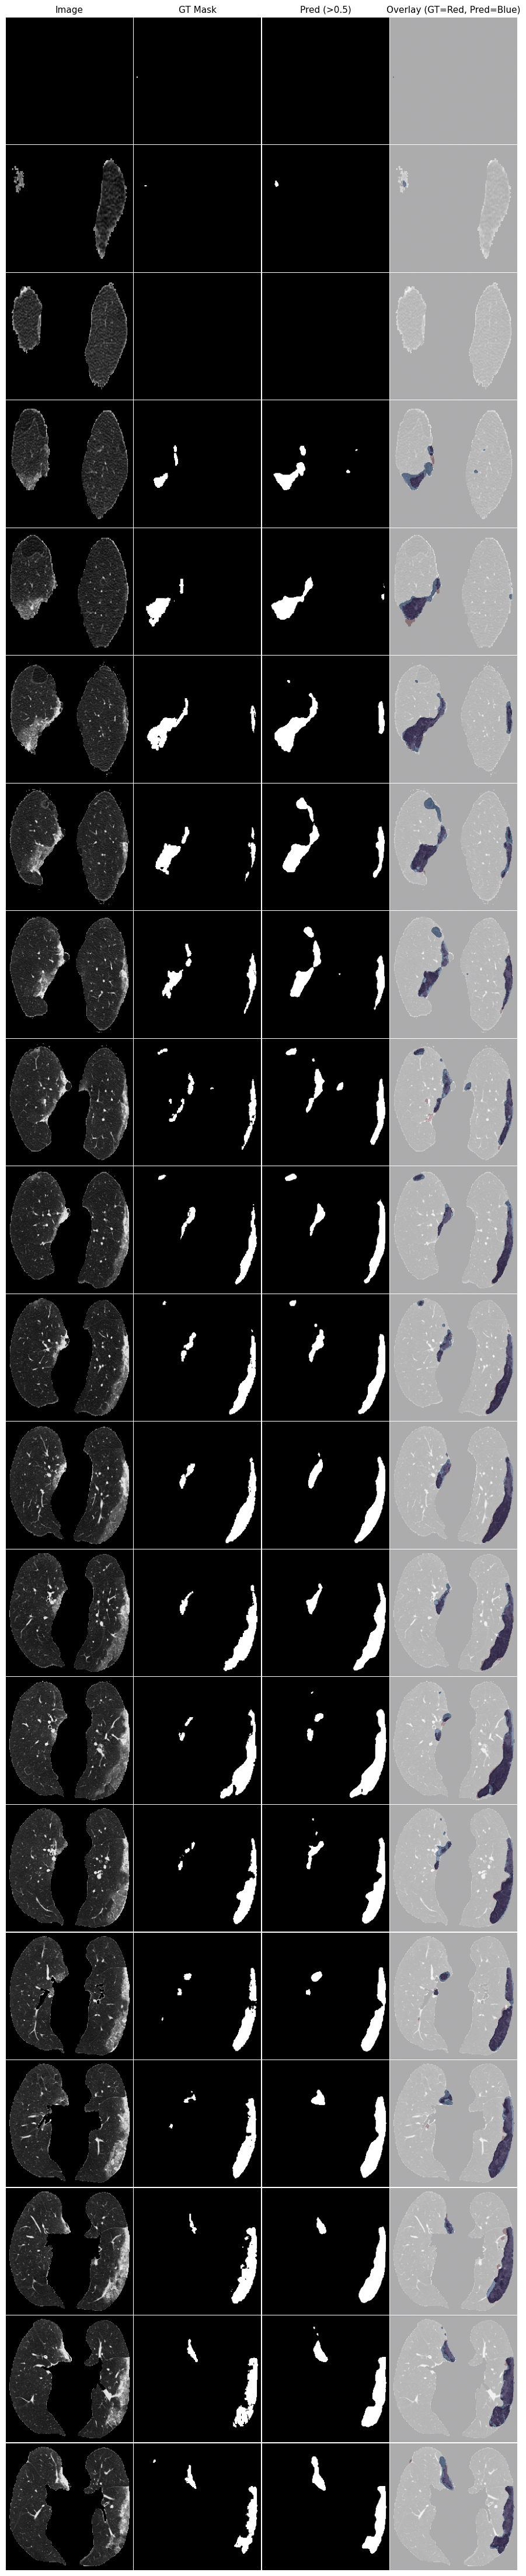

In [21]:
THRESH = 0.5

def visualize_test_square_grid(model, ds, n=20, thresh=0.5, alpha=0.45):
    xs, ys = [], []

    for xb, yb in ds:
        xs.append(xb.numpy())
        ys.append(yb.numpy())
        if sum(x.shape[0] for x in xs) >= n:
            break

    X = np.concatenate(xs, axis=0)[:n]
    Y = np.concatenate(ys, axis=0)[:n]

    if Y.ndim == 4:
        Y = Y[..., 0]
    else:
        Y = Y.squeeze()

    pred = model.predict(X, verbose=0)
    if pred.ndim == 4:
        pred = pred[..., 0]

    pred_bin = (pred > thresh).astype(np.float32)

    cell = 2.2
    fig_w = 4 * cell
    fig_h = n * cell

    fig, axes = plt.subplots(
        nrows=n,
        ncols=4,
        figsize=(fig_w, fig_h),
        gridspec_kw={"wspace": 0.005, "hspace": 0.005}
    )

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    def make_square(ax):
        if hasattr(ax, "set_box_aspect"):
            ax.set_box_aspect(1)
        else:
            ax.set_aspect("equal", adjustable="box")

    for i in range(n):
        gray = X[i][..., 0]
        gt   = Y[i]
        pr   = pred_bin[i]

        ax = axes[i, 0]
        ax.imshow(gray, cmap="gray")
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Image", fontsize=11)

        ax = axes[i, 1]
        ax.imshow(gt, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("GT Mask", fontsize=11)

        ax = axes[i, 2]
        ax.imshow(pr, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Pred (>{thresh})", fontsize=11)

        ax = axes[i, 3]
        ax.imshow(gray, cmap="gray")
        ax.imshow(gt, alpha=alpha, cmap="Reds", vmin=0, vmax=1)
        ax.imshow(pr, alpha=alpha, cmap="Blues", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Overlay (GT=Red, Pred=Blue)", fontsize=11)

    plt.subplots_adjust(left=0.002, right=0.998, top=0.995, bottom=0.002)
    plt.show()

visualize_test_square_grid(best_model, test_ds, n=20, thresh=THRESH, alpha=0.45)

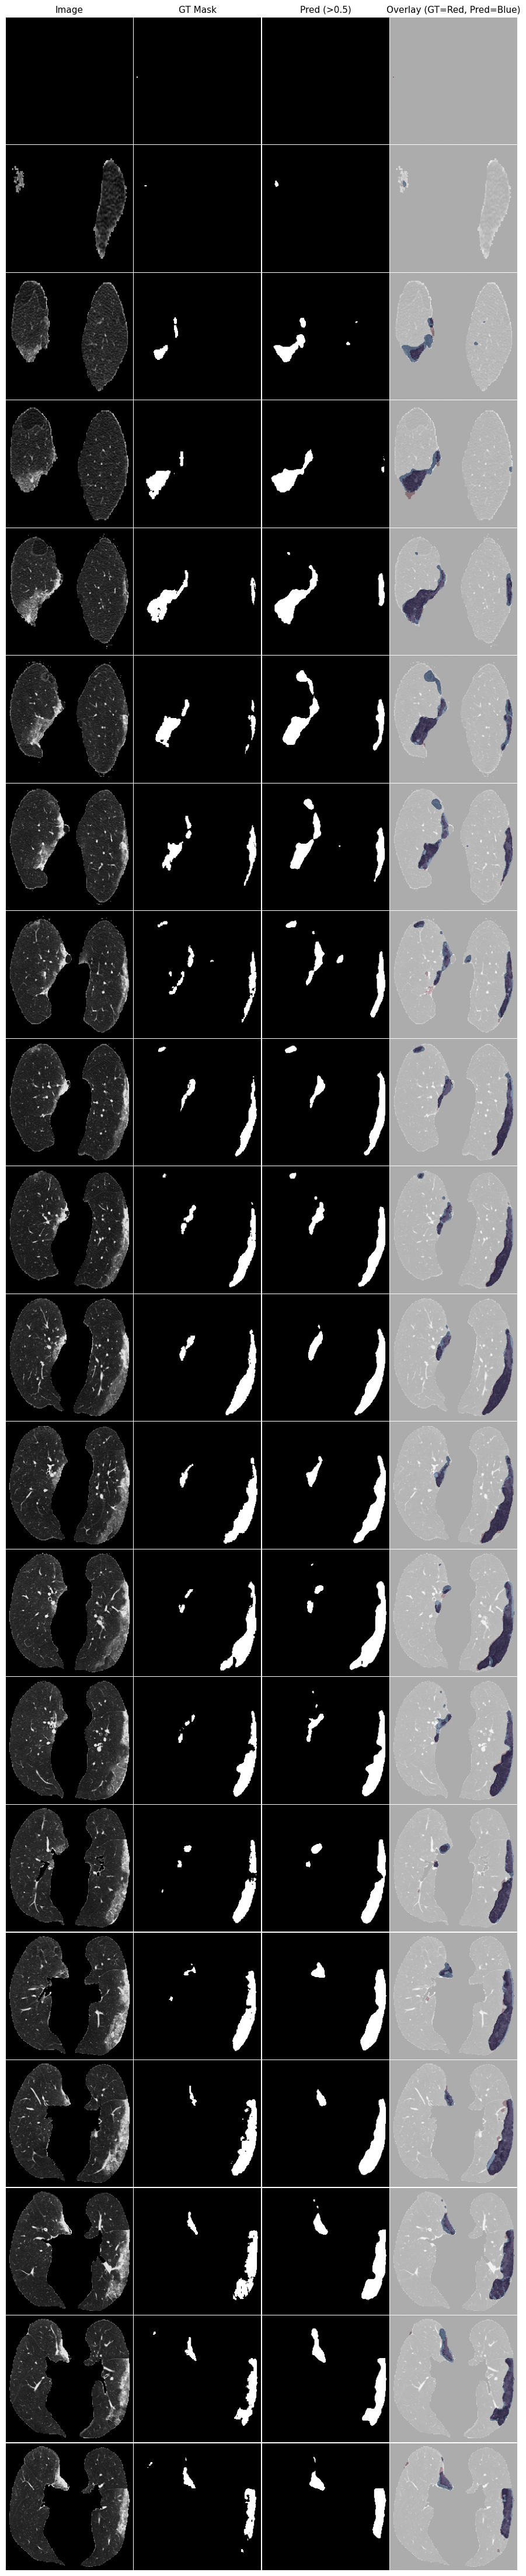

In [22]:
def visualize_positive_test_square_grid(model, ds, n=20, thresh=0.5, alpha=0.45):
    xs, ys = [], []

    for xb, yb in ds:
        x_np = xb.numpy()
        y_np = yb.numpy()

        for i in range(x_np.shape[0]):
            if np.any(y_np[i] > 0):
                xs.append(x_np[i])
                ys.append(y_np[i])
            if len(xs) >= n:
                break

        if len(xs) >= n:
            break

    if len(xs) == 0:
        print("Không tìm thấy mẫu test nào có tổn thương.")
        return

    X = np.stack(xs[:n], axis=0)
    Y = np.stack(ys[:n], axis=0)

    if Y.ndim == 4:
        Y = Y[..., 0]
    else:
        Y = Y.squeeze()

    pred = model.predict(X, verbose=0)
    if pred.ndim == 4:
        pred = pred[..., 0]

    pred_bin = (pred > thresh).astype(np.float32)

    cell = 2.2
    fig_w = 4 * cell
    fig_h = len(X) * cell

    fig, axes = plt.subplots(
        nrows=len(X),
        ncols=4,
        figsize=(fig_w, fig_h),
        gridspec_kw={"wspace": 0.005, "hspace": 0.005}
    )

    if len(X) == 1:
        axes = np.expand_dims(axes, axis=0)

    def make_square(ax):
        if hasattr(ax, "set_box_aspect"):
            ax.set_box_aspect(1)
        else:
            ax.set_aspect("equal", adjustable="box")

    for i in range(len(X)):
        gray = X[i][..., 0]
        gt   = Y[i]
        pr   = pred_bin[i]

        ax = axes[i, 0]
        ax.imshow(gray, cmap="gray")
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Image", fontsize=11)

        ax = axes[i, 1]
        ax.imshow(gt, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("GT Mask", fontsize=11)

        ax = axes[i, 2]
        ax.imshow(pr, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Pred (>{thresh})", fontsize=11)

        ax = axes[i, 3]
        ax.imshow(gray, cmap="gray")
        ax.imshow(gt, alpha=alpha, cmap="Reds", vmin=0, vmax=1)
        ax.imshow(pr, alpha=alpha, cmap="Blues", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Overlay (GT=Red, Pred=Blue)", fontsize=11)

    plt.subplots_adjust(left=0.002, right=0.998, top=0.995, bottom=0.002)
    plt.show()

visualize_positive_test_square_grid(best_model, test_ds, n=20, thresh=THRESH, alpha=0.45)

In [23]:
SAVE_DIR = "/kaggle/working/prediction_results"
os.makedirs(SAVE_DIR, exist_ok=True)

xs, ys = [], []
for xb, yb in test_ds:
    xs.append(xb.numpy())
    ys.append(yb.numpy())

X_all = np.concatenate(xs, axis=0)
Y_all = np.concatenate(ys, axis=0)
P_all = best_model.predict(X_all, verbose=0)
P_bin = (P_all > THRESH).astype(np.float32)

num_save = min(10, len(X_all))

for i in range(num_save):
    img = (X_all[i][..., 0] * 255).astype(np.uint8)
    gt = (Y_all[i][..., 0] * 255).astype(np.uint8)
    pred = (P_bin[i][..., 0] * 255).astype(np.uint8)

    cv2.imwrite(os.path.join(SAVE_DIR, f"{i:03d}_ct.png"), img)
    cv2.imwrite(os.path.join(SAVE_DIR, f"{i:03d}_gt.png"), gt)
    cv2.imwrite(os.path.join(SAVE_DIR, f"{i:03d}_pred.png"), pred)

print("Đã lưu vào:", SAVE_DIR)

2026-04-18 12:04:56.269961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:04:56.413103: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:04:56.556764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:05:00.328703: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 12:05:00.469497: E external/local_xla/xla/stream_

Đã lưu vào: /kaggle/working/prediction_results


In [24]:
print("===== SUMMARY =====")
print("Train samples (Dataset3):", len(train_triplets))
print("Val samples   (Dataset3):", len(val_triplets))
print("Test samples  (Dataset2):", len(test_triplets))
print("Best model    : novel_unet_best.keras")

===== SUMMARY =====
Train samples (Dataset3): 2949
Val samples   (Dataset3): 571
Test samples  (Dataset2): 829
Best model    : novel_unet_best.keras
